In [24]:
import pandas as pd
import numpy as np

file_path = r'c:/Users/neham/Downloads/archive (3)/tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations     2640 non-null   int64         
 12  date                  2640 non-null   datetime64[ns]
dtypes: datetime64[ns](

<Figure size 1000x400 with 0 Axes>

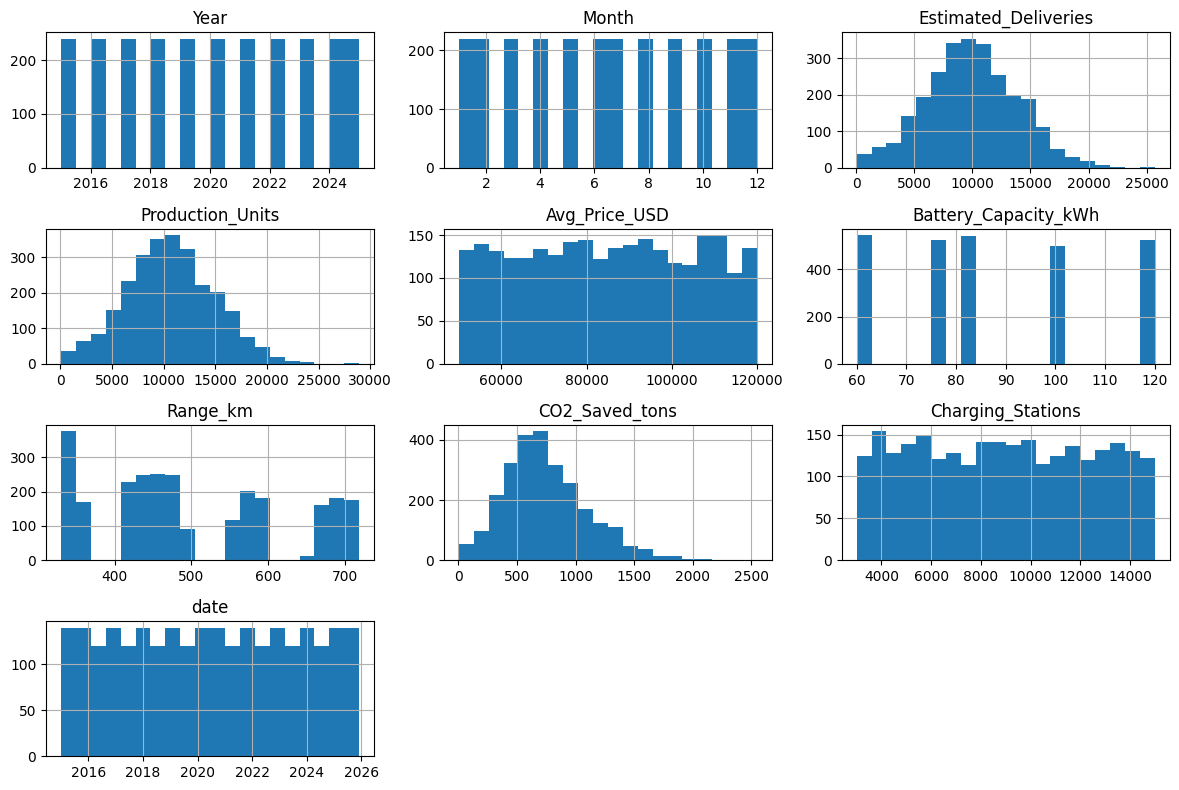

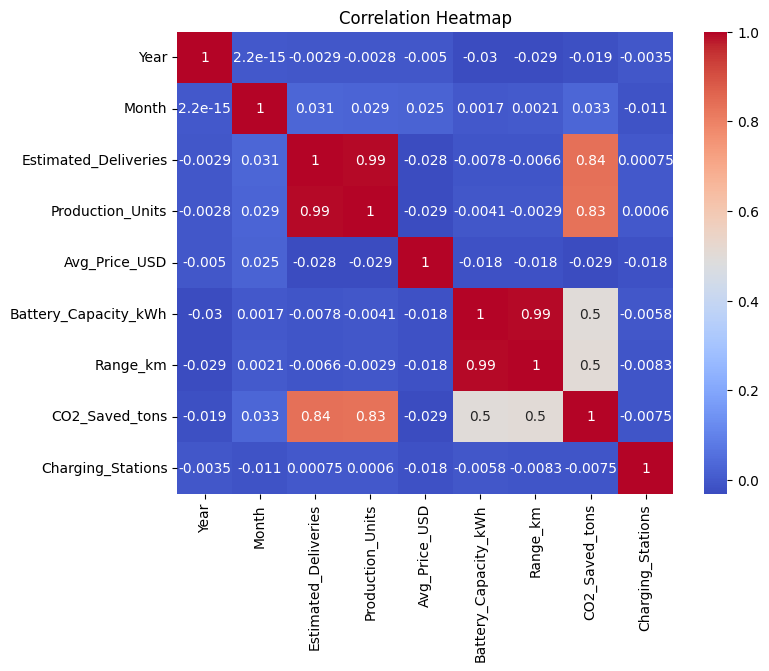

In [25]:

import matplotlib.pyplot as plt
import seaborn as sns

df.info()
df.describe()
df.isnull().sum()

plt.figure(figsize=(10,4))
df.hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [32]:
# Feature Engineering
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['dayofweek'] = df['date'].dt.dayofweek

df = df.ffill()
# Only encode categorical columns that exist and are not already encoded
categorical_cols = []
for col in ['Region', 'Model', 'Source_Type']:
    if col in df.columns and str(df[col].dtype) in ['object', 'category', 'string']:
        categorical_cols.append(col)
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols)

df['Estimated_Deliveries_lag1'] = df['Estimated_Deliveries'].shift(1)
df['Estimated_Deliveries_rolling3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Ensure target and features exist and are valid
if 'Estimated_Deliveries' in df.columns:
    drop_cols = [col for col in ['Estimated_Deliveries', 'date'] if col in df.columns]
    features = df.drop(drop_cols, axis=1, errors='ignore').select_dtypes(include=[np.number])
    target = df['Estimated_Deliveries']

    # Remove rows with NaN or infinite values in features or target
    valid_idx = features.replace([np.inf, -np.inf], np.nan).dropna().index
    valid_idx = valid_idx.intersection(target.replace([np.inf, -np.inf], np.nan).dropna().index)
    features = features.loc[valid_idx]
    target = target.loc[valid_idx]

    if len(features) > 0 and len(target) > 0:
        X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

        lr = LinearRegression()
        lr.fit(X_train, y_train)
        y_pred_lr = lr.predict(X_test)
        print('Linear Regression RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))
        print('Linear Regression MAE:', mean_absolute_error(y_test, y_pred_lr))

        rf = RandomForestRegressor(random_state=42)
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        print('Random Forest RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
        print('Random Forest MAE:', mean_absolute_error(y_test, y_pred_rf))
    else:
        print('No valid data available for modeling after removing NaN/infinite values.')
else:
    print('Estimated_Deliveries column not found in DataFrame.')

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [37]:
from sklearn.model_selection import GridSearchCV

# Ensure X_train and y_train exist and are valid
if 'X_train' in locals() and 'y_train' in locals():
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    }
    grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_squared_error')
    grid_search.fit(X_train, y_train)
    print('Best Params:', grid_search.best_params_)
    best_rf = grid_search.best_estimator_
    y_pred_best_rf = best_rf.predict(X_test)
    print('Tuned Random Forest RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_best_rf)))
else:
    print('X_train or y_train not found. Please run the previous cell successfully.')

KeyboardInterrupt: 

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Fix 2: Use Estimated_Deliveries and group by date
ts = df.groupby('date')['Estimated_Deliveries'].sum().sort_index()
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)
plt.figure(figsize=(10,5))
plt.plot(ts, label='Actual')
plt.plot(pd.date_range(ts.index[-1], periods=13, freq='M')[1:], forecast, label='Forecast', linestyle='--')
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

In [15]:

output_path = 'processed_data.csv'
df.to_csv(output_path, index=False)
print(f"Data exported to {output_path}")

Data exported to processed_data.csv
